# **Python Class 15 – Data Operations in Pandas & Introduction to Matplotlib**

In the previous lesson, we explored the foundations of **pandas**, including DataFrames, indexing, slicing, and powerful tools. Today, we continue building real data-analysis skills by learning how to **manipulate, clean, and prepare data** — tasks that every data scientist performs daily.

We will also begin our journey into **data visualization** using Matplotlib, the most fundamental plotting library in Python. This lesson bridges the gap between **data processing** and **data interpretation**.

---

## **What We Will Learn Today**

### **1. Essential Data Operations in Pandas**

You will learn how to:

* Access and subset data using `loc` and `iloc`

* Use NumPy ufuncs and pandas broadcasting for efficient vectorized computations

These operations are the core of practical data analysis pipelines.

---

### **2. Handling Missing Data**

Real-world datasets are never clean. Pandas provides powerful tools to detect and fix problems like:

* missing values (`isna`, `notna`)
* filling values (`fillna`)
* removing incomplete rows/columns (`dropna`)
* replacing invalid values
  Understanding missing data is critical in machine learning and analytics.

---

### **3. Introduction to Matplotlib**

Before moving to advanced visualization libraries like Seaborn or Plotly, you must master the basics.

We will start with Matplotlib’s core plotting interface:

* creating simple plots
* customizing axes, colors, markers, legends
* saving figures

And we’ll focus on essential plot types:

#### **✓ Line Plot**

Great for trends and time series.

#### **✓ Scatter Plot**

Used to visualize relationships between variables.

#### **✓ Visualizing Errors**

Using:

* error bars
* confidence intervals
* standard deviation shading

This is key in scientific and machine-learning reporting.

#### **✓ Contour Plots**

Useful for visualizing functions of two variables or loss landscapes.

#### **✓ Introduction to 3D Plotting**

We will learn how to:

* create a 3D axis
* plot 3D curves
* render surfaces

This becomes useful in optimization, mathematics, and ML model visualization.

---

## **Why This Lesson Matters**

By the end of today’s class, you’ll be able to:

* clean real datasets and prepare them for machine learning
* perform complex operations with just a few lines of pandas code
* visualize patterns, trends, and relationships in data
* understand the foundations of scientific plotting

This lesson marks your transition from writing Python code to analyzing and visualizing real data — the core skillset of a modern data scientist.

# Operating on Data in Pandas

One of the essential pieces of NumPy is the ability to perform quick element-wise operations, both with basic arithmetic (addition, subtraction, multiplication, etc.) and with more sophisticated operations (trigonometric functions, exponential and logarithmic functions, etc.).
Pandas inherits much of this functionality from NumPy, and the ufuncs that we encountered in Numpy are still relevent.

Pandas includes a couple useful twists, however: for unary operations like negation and trigonometric functions, these ufuncs will *preserve index and column labels* in the output, and for binary operations such as addition and multiplication, Pandas will automatically *align indices* when passing the objects to the ufunc.
This means that keeping the context of data and combining data from different sources–both potentially error-prone tasks with raw NumPy arrays–become essentially foolproof ones with Pandas.
We will additionally see that there are well-defined operations between one-dimensional ``Series`` structures and two-dimensional ``DataFrame`` structures.

## Ufuncs: Index Preservation

Because Pandas is designed to work with NumPy, any NumPy ufunc will work on Pandas ``Series`` and ``DataFrame`` objects.
Let's start by defining a simple ``Series`` and ``DataFrame`` on which to demonstrate this:

In [9]:
import numpy as np
import pandas as pd

In [10]:
rng = np.random.RandomState(42)
ser = pd.Series(rng.randint(0, 10, 4))
ser

,0
0,6
1,3
2,7
3,4


In [11]:
rng = np.random.RandomState(42)
df = pd.DataFrame(rng.randint(0, 10, (3, 4)),
                  columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,6,3,7,4
1,6,9,2,6
2,7,4,3,7


If we apply a NumPy ufunc on either of these objects, the result will be another Pandas object *with the indices preserved:*

In [12]:
np.exp(ser)

,0
0,403.428793
1,20.085537
2,1096.633158
3,54.598150


Or, for a slightly more complex calculation:

In [13]:
np.sin(df * np.pi / 4)

,A,B,C,D
0,-1.000000,7.071068e-01,-0.707107,1.224647e-16
1,-1.000000,7.071068e-01,1.000000,-1.000000e+00
2,-0.707107,1.224647e-16,0.707107,-7.071068e-01


## UFuncs: Index Alignment

For binary operations on two ``Series`` or ``DataFrame`` objects, Pandas will align indices in the process of performing the operation.
This is very convenient when working with incomplete data, as we'll see in some of the examples that follow.

### Index alignment in Series

As an example, suppose we are combining two different data sources, and find only the top three US states by *area* and the top three US states by *population*:

In [14]:
area = pd.Series({'Alaska': 1723337, 'Texas': 695662,
                  'California': 423967}, name='area')
population = pd.Series({'California': 38332521, 'Texas': 26448193,
                        'New York': 19651127}, name='population')

Let's see what happens when we divide these to compute the population density:

In [15]:
population / area

,0
Alaska,NaN
California,90.413926
New York,NaN
Texas,38.018740


The resulting array contains the *union* of indices of the two input arrays, which could be determined using standard Python set arithmetic on these indices:

In [16]:
area.index

Index(['Alaska', 'Texas', 'California'], dtype='object')

In [17]:
population.index

Index(['California', 'Texas', 'New York'], dtype='object')

In [18]:
area.index.union(population.index)

Index(['Alaska', 'California', 'New York', 'Texas'], dtype='object')

Any item for which one or the other does not have an entry is marked with ``NaN``, or "Not a Number," which is how Pandas marks missing data.
This index matching is implemented this way for any of Python's built-in arithmetic expressions; any missing values are filled in with NaN by default:

In [19]:
A = pd.Series([2, 4, 6], index=[0, 1, 2])
B = pd.Series([1, 3, 5], index=[1, 2, 3])
A + B

,0
0,NaN
1,5.0
2,9.0
3,NaN


If using NaN values is not the desired behavior, the fill value can be modified using appropriate object methods in place of the operators.
For example, calling ``A.add(B)`` is equivalent to calling ``A + B``, but allows optional explicit specification of the fill value for any elements in ``A`` or ``B`` that might be missing:

In [20]:
A.add(B, fill_value=0)

,0
0,2.0
1,5.0
2,9.0
3,5.0


Here’s why you get **2** at index **0** and **5** at index **3**.

---

## **Why `A.add(B, fill_value=0)` gives these results**

Your original Series:

```
A:
0    2
1    4
2    6

B:
1    1
2    3
3    5
```

### **Step 1 — Align indices**

Pandas aligns by index:

| Index | A   | B   |
| ----- | --- | --- |
| 0     | 2   | NaN |
| 1     | 4   | 1   |
| 2     | 6   | 3   |
| 3     | NaN | 5   |

---

### **Step 2 — Apply `fill_value=0`**

Missing values become **0** before addition:

| Index | A | B | After filling |
| ----- | - | - | ------------- |
| 0     | 2 | 0 |               |
| 1     | 4 | 1 |               |
| 2     | 6 | 3 |               |
| 3     | 0 | 5 |               |

---

### **Step 3 — Perform addition**

* **Index 0:** 2 + 0 = **2**
* **Index 1:** 4 + 1 = **5**
* **Index 2:** 6 + 3 = **9**
* **Index 3:** 0 + 5 = **5**

So the result is:

```
0    2.0
1    5.0
2    9.0
3    5.0
```

---

## **Summary**

You got **2** at index **0** because:

> A has value **2**, B is missing → filled with **0** → 2 + 0 = 2.

You got **5** at index **3** because:

> A is missing → filled with **0**, B has **5** → 0 + 5 = 5.


### Index alignment in DataFrame

A similar type of alignment takes place for *both* columns and indices when performing operations on ``DataFrame``s:

In [132]:
A = pd.DataFrame(rng.randint(0, 20, (2, 2)),
                 columns=list('AB'))
A

,A,B
0,19,14
1,18,11


In [133]:
B = pd.DataFrame(rng.randint(0, 10, (3, 3)),
                 columns=list('BAC'))
B

,B,A,C
0,4,9,0
1,6,9,2
2,4,7,3


In [134]:
A + B

,A,B,C
0,28.0,18.0,NaN
1,27.0,17.0,NaN
2,NaN,NaN,NaN


Notice that indices are aligned correctly irrespective of their order in the two objects, and indices in the result are sorted.
As was the case with ``Series``, we can use the associated object's arithmetic method and pass any desired ``fill_value`` to be used in place of missing entries.
Here we'll fill with the mean of all values in ``A`` (computed by first stacking the rows of ``A``):

In [135]:
A.stack()


0  A    19
   B    14
1  A    18
   B    11
dtype: int64

In [136]:
fill = A.stack().mean()
fill

np.float64(15.5)

In [140]:
fill = A.stack().mean()
A.add(B, fill_value=fill)

,A,B,C
0,28.0,18.0,15.5
1,27.0,17.0,17.5
2,22.5,19.5,18.5


The following table lists Python operators and their equivalent Pandas object methods:

| Python Operator | Pandas Method(s)                      |
|-----------------|---------------------------------------|
| ``+``           | ``add()``                             |
| ``-``           | ``sub()``, ``subtract()``             |
| ``*``           | ``mul()``, ``multiply()``             |
| ``/``           | ``truediv()``, ``div()``, ``divide()``|
| ``//``          | ``floordiv()``                        |
| ``%``           | ``mod()``                             |
| ``**``          | ``pow()``                             |


## Ufuncs: Operations Between DataFrame and Series

When performing operations between a ``DataFrame`` and a ``Series``, the index and column alignment is similarly maintained.
Operations between a ``DataFrame`` and a ``Series`` are similar to operations between a two-dimensional and one-dimensional NumPy array.
Consider one common operation, where we find the difference of a two-dimensional array and one of its rows:

In [26]:
A = rng.randint(10, size=(3, 4))
A

array([[6, 3, 8, 2],
       [4, 2, 6, 4],
       [8, 6, 1, 3]])

In [27]:
A - A[0]

array([[ 0,  0,  0,  0],
       [-2, -1, -2,  2],
       [ 2,  3, -7,  1]])

According to NumPy's broadcasting rules, subtraction between a two-dimensional array and one of its rows is applied row-wise.

In Pandas, the convention similarly operates row-wise by default:

In [28]:
df = pd.DataFrame(A, columns=list('QRST'))
# print(df.iloc[0])
df - df.iloc[0]

,Q,R,S,T
0,0,0,0,0
1,-2,-1,-2,2
2,2,3,-7,1


## **Understanding `loc` and `iloc` in Pandas**

In [29]:
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
}, index=['a', 'b', 'c'])

# Access row with label 'b' and column 'A'
print(df.loc['b', 'A'], end = '\n\n')  # Output: 2

# Slice rows 'a' to 'b' (inclusive) and columns 'A' and 'B'
print(df.loc['a':'b', ['A', 'B']], end = '\n\n')

print(df.iloc[0], end = '\n\n')

2

   A  B
a  1  4
b  2  5

A    1
B    4
C    7
Name: a, dtype: int64



###  **`loc` — Label-based indexing**

* Uses **row and column labels** (names).
* Slicing is **inclusive**.
* Works with strings, index names, column names.


In [30]:
print(df.loc['b', 'A'], end = '\n\n')       # Access row labeled 'b' and column 'A'
print(df.loc['a':'b', ['A','B']], end = '\n\n')   # Slice rows by label and select specific columns

2

   A  B
a  1  4
b  2  5



###  **`iloc` — Position-based indexing**

* Uses **integer positions** (0-based).
* Works like standard Python indexing.
* Slicing is **exclusive at the end**.


In [31]:
print(df.iloc[0], end = '\n\n')        # First row (position 0)
print(df.iloc[0:2, 1], end = '\n\n')   # Rows 0–1, column at position 1

A    1
B    4
C    7
Name: a, dtype: int64

a    4
b    5
Name: B, dtype: int64



### **Summary Table**

| Method | Indexing Type     | Example           | Use Case                             |
| ------ | ----------------- | ----------------- | ------------------------------------ |
| `loc`  | Labels            | `df.loc['b','A']` | When working with named rows/columns |
| `iloc` | Integer positions | `df.iloc[0,0]`    | When working with numeric indexes    |


If you would instead like to operate column-wise, you can use the object methods mentioned earlier, while specifying the ``axis`` keyword:

In [32]:
df.subtract(df['A'], axis=0)

,A,B,C
a,0,3,6
b,0,3,6
c,0,3,6


Note that these ``DataFrame``/``Series`` operations, like the operations discussed above, will automatically align  indices between the two elements:

In [33]:
aa = pd.Series([1, 2, 3, 4], index =['a', 'b', "c0", 's'])
aa

,0
a,1
b,2
c0,3
s,4


In [34]:
aa['a']

np.int64(1)

In [35]:
halfrow = df.iloc[0, ::2]
halfrow

,a
A,1
C,7


In [36]:
df - halfrow
# print(df)
# df.subtract(halfrow, axis=1)

,A,B,C
a,0.0,NaN,0.0
b,1.0,NaN,1.0
c,2.0,NaN,2.0


This preservation and alignment of indices and columns means that operations on data in Pandas will always maintain the data context, which prevents the types of silly errors that might come up when working with heterogeneous and/or misaligned data in raw NumPy arrays.

# Handling Missing Data

The difference between data found in many tutorials and data in the real world is that real-world data is rarely clean and homogeneous.
In particular, many interesting datasets will have some amount of data missing.
To make matters even more complicated, different data sources may indicate missing data in different ways.

In this section, we will discuss some general considerations for missing data, discuss how Pandas chooses to represent it, and demonstrate some built-in Pandas tools for handling missing data in Python.
Here and throughout the book, we'll refer to missing data in general as *null*, *NaN*, or *NA* values.

## ``None``: Pythonic missing data

The first sentinel value used by Pandas is ``None``, a Python singleton object that is often used for missing data in Python code.
Because it is a Python object, ``None`` cannot be used in any arbitrary NumPy/Pandas array, but only in arrays with data type ``'object'`` (i.e., arrays of Python objects):

In [37]:
vals1 = np.array([1, None, 3, 4])
vals1

array([1, None, 3, 4], dtype=object)

This ``dtype=object`` means that the best common type representation NumPy could infer for the contents of the array is that they are Python objects.
While this kind of object array is useful for some purposes, any operations on the data will be done at the Python level, with much more overhead than the typically fast operations seen for arrays with native types:

In [38]:
for dtype in ['object', 'int']:
    print("dtype =", dtype)
    %timeit np.arange(1E6, dtype=dtype).sum()
    print()

dtype = object
79.7 ms ± 667 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)

dtype = int
1.04 ms ± 215 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)



The use of Python objects in an array also means that if you perform aggregations like ``sum()`` or ``min()`` across an array with a ``None`` value, you will generally get an error:

In [40]:
vals1.sum()

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

This reflects the fact that addition between an integer and ``None`` is undefined.

## ``NaN``: Missing numerical data

We already know another missing data representation, ``NaN`` (acronym for *Not a Number*), which is a special floating-point value recognized by all systems that use the standard IEEE floating-point representation.

In [42]:
vals2 = np.array([1, np.nan, 3, 4])
vals2.dtype

dtype('float64')

In [43]:
vals2.sum(), vals2.min(), vals2.max()

(np.float64(nan), np.float64(nan), np.float64(nan))

In [44]:
np.nansum(vals2), np.nanmin(vals2), np.nanmax(vals2)

(np.float64(8.0), np.float64(1.0), np.float64(4.0))

## NaN and None in Pandas

``NaN`` and ``None`` both have their place, and Pandas is built to handle the two of them nearly interchangeably, converting between them where appropriate:

In [45]:
pd.Series([1, np.nan, 2, None])

,0
0,1.0
1,NaN
2,2.0
3,NaN


For types that don't have an available sentinel value, Pandas automatically type-casts when NA values are present.
For example, if we set a value in an integer array to ``np.nan``, it will automatically be upcast to a floating-point type to accommodate the NA:

In [46]:
x = pd.Series(range(2), dtype=int)
x

,0
0,0
1,1


In [47]:
x[0] = None
x

,0
0,NaN
1,1.0


In [48]:
x = pd.Series([None, 2], dtype=object)
x

,0
0,None
1,2


Notice that in addition to casting the integer array to floating point, Pandas automatically converts the ``None`` to a ``NaN`` value.
(Be aware that there is a proposal to add a native integer NA to Pandas in the future; as of this writing, it has not been included).

While this type of magic may feel a bit hackish compared to the more unified approach to NA values in domain-specific languages like R, the Pandas sentinel/casting approach works quite well in practice and in my experience only rarely causes issues.

The following table lists the upcasting conventions in Pandas when NA values are introduced:

|Typeclass     | Conversion When Storing NAs | NA Sentinel Value      |
|--------------|-----------------------------|------------------------|
| ``floating`` | No change                   | ``np.nan``             |
| ``object``   | No change                   | ``None`` or ``np.nan`` |
| ``integer``  | Cast to ``float64``         | ``np.nan``             |
| ``boolean``  | Cast to ``object``          | ``None`` or ``np.nan`` |

Keep in mind that in Pandas, string data is always stored with an ``object`` dtype.

## Operating on Null Values

As we have seen, Pandas treats ``None`` and ``NaN`` as essentially interchangeable for indicating missing or null values.
To facilitate this convention, there are several useful methods for detecting, removing, and replacing null values in Pandas data structures.
They are:

- ``isnull()``: Generate a boolean mask indicating missing values
- ``notnull()``: Opposite of ``isnull()``
- ``dropna()``: Return a filtered version of the data
- ``fillna()``: Return a copy of the data with missing values filled or imputed

We will conclude this section with a brief exploration and demonstration of these routines.

## Detecting null values
Pandas data structures have two useful methods for detecting null data: ``isnull()`` and ``notnull()``.
Either one will return a Boolean mask over the data. For example:

In [49]:
data = pd.Series([1, np.nan, 'hello', None])

In [50]:
data.isnull()

,0
0,False
1,True
2,False
3,True


As we know already, Boolean masks can be used directly as a ``Series`` or ``DataFrame`` index:

In [51]:
data[data.notnull()]

,0
0,1
2,hello


The ``isnull()`` and ``notnull()`` methods produce similar Boolean results for ``DataFrame``s.

### Dropping null values

In addition to the masking used before, there are the convenience methods, ``dropna()``
(which removes NA values) and ``fillna()`` (which fills in NA values). For a ``Series``,
the result is straightforward:

In [52]:
print(data)
data.dropna()

0        1
1      NaN
2    hello
3     None
dtype: object


,0
0,1
2,hello


For a ``DataFrame``, there are more options.
Consider the following ``DataFrame``:

In [53]:
df = pd.DataFrame([[1,      np.nan, 2],
                   [2,      3,      5],
                   [np.nan, 4,      6]])
df

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


We cannot drop single values from a ``DataFrame``; we can only drop full rows or full columns.
Depending on the application, you might want one or the other, so ``dropna()`` gives a number of options for a ``DataFrame``.

By default, ``dropna()`` will drop all rows in which *any* null value is present:

In [54]:
df.dropna(axis=1)

,2
0,2
1,5
2,6


Alternatively, you can drop NA values along a different axis; ``axis=1`` drops all columns containing a null value:

In [55]:
df.dropna(axis='rows')

,0,1,2
1,2.0,3.0,5


But this drops some good data as well; you might rather be interested in dropping rows or columns with *all* NA values, or a majority of NA values.
This can be specified through the ``how`` or ``thresh`` parameters, which allow fine control of the number of nulls to allow through.

The default is ``how='any'``, such that any row or column (depending on the ``axis`` keyword) containing a null value will be dropped.
You can also specify ``how='all'``, which will only drop rows/columns that are *all* null values:

In [56]:
df[3] = np.nan
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [57]:
df.dropna(axis='columns', how='all')

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


For finer-grained control, the ``thresh`` parameter lets you specify a minimum number of non-null values for the row/column to be kept:

In [58]:
df.dropna(axis='rows', thresh=3)

,0,1,2,3
1,2.0,3.0,5,NaN


Here the first and last row have been dropped, because they contain only two non-null values.

### Filling null values

Sometimes rather than dropping NA values, you'd rather replace them with a valid value.
This value might be a single number like zero, or it might be some sort of imputation or interpolation from the good values.
You could do this in-place using the ``isnull()`` method as a mask, but because it is such a common operation Pandas provides the ``fillna()`` method, which returns a copy of the array with the null values replaced.

Consider the following ``Series``:

In [59]:
data = pd.Series([1, np.nan, 2, None, 3], index=list('abcde'))
data

,0
a,1.0
b,NaN
c,2.0
d,NaN
e,3.0


We can fill NA entries with a single value, such as zero:

In [60]:
data.fillna(78)

,0
a,1.0
b,78.0
c,2.0
d,78.0
e,3.0


We can specify a forward-fill to propagate the previous value forward:

In [61]:
# forward-fill
data.fillna(method='ffill')

/tmp/ipython-input-3316037056.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill')


,0
a,1.0
b,1.0
c,2.0
d,2.0
e,3.0


Or we can specify a back-fill to propagate the next values backward:

In [62]:
# back-fill
data.fillna(method='bfill')

/tmp/ipython-input-692461307.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill')


,0
a,1.0
b,2.0
c,2.0
d,3.0
e,3.0


For ``DataFrame``s, the options are similar, but we can also specify an ``axis`` along which the fills take place:

In [63]:
df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [64]:
df.fillna(method='ffill', axis=1)

/tmp/ipython-input-901808322.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=1)


,0,1,2,3
0,1.0,1.0,2.0,2.0
1,2.0,3.0,5.0,5.0
2,NaN,4.0,6.0,6.0


Notice that if a previous value is not available during a forward fill, the NA value remains.

# Visualize with Matplotlib
Matplotlib is a Python 2D plotting library which produces publication quality figures in a variety of hardcopy formats and interactive environments across platforms. Matplotlib can be used in Python scripts, the Python and IPython shells, the Jupyter notebook and web application servers.

## Import Matplotlib
The **plt** interface is what we will use most often.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl # will be used for dates

#Line Plots

For all Matplotlib plots, we start by creating a figure and an axes. In their simplest form, a figure and axes can be created as follows:

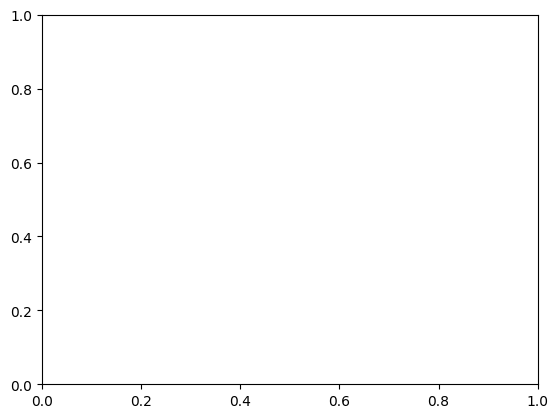

In [66]:
fig = plt.figure()
ax = plt.axes()

In Matplotlib, the *figure* (an instance of the class plt.Figure) can be thought of as a single container that contains all the objects representing axes, graphics, text, and labels. The axes (an instance of the class plt.Axes) is what we see above: a bounding box with ticks and labels, which will eventually contain the plot elements that make up our visualization.

Once we have created an axes, we can use the ax.plot function to plot some data. Let's start with a simple sinusoid:

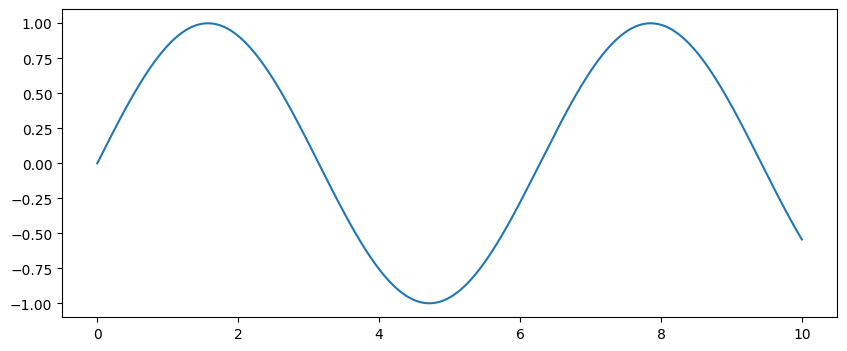

In [67]:
plt.figure(figsize=(10, 4))
ax = plt.axes()
x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x))# ;
plt.show()

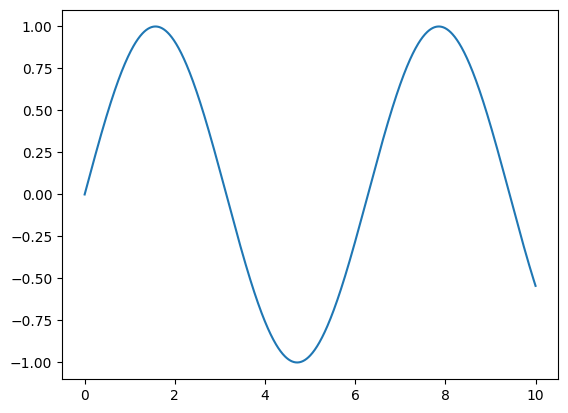

In [68]:
ax = plt.axes()
x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x))
plt.show()

Alternatively, we can use the pylab interface and let the figure and axes be created for us in the background:

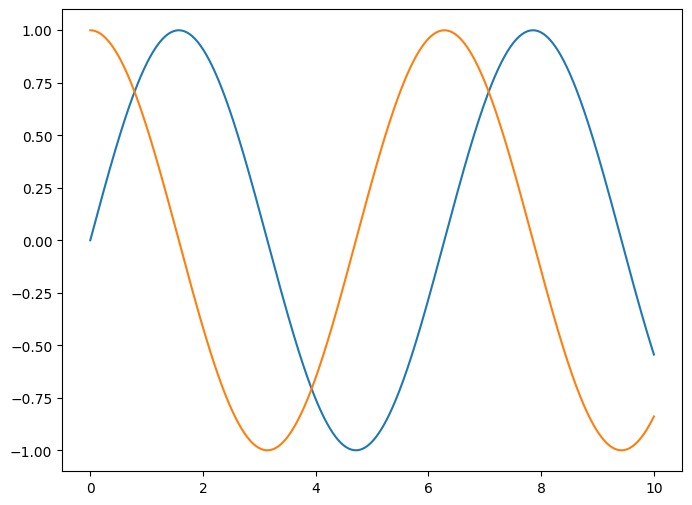

In [69]:
# if we want to change the default figsize,
# so that we won't have to specify each time
plt.rcParams['figure.figsize'] = 8, 6

# If we want to create a single figure with multiple lines,
# we can simply call the plot function multiple times
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x));

## Adjusting the Plot: Line Colors and Styles
The first adjustment you might wish to make to a plot is to control the line colors and styles. The plt.plot() function takes additional arguments that can be used to specify these. To adjust the color, you can use the color keyword, which accepts a string argument representing virtually any imaginable color. The color can be specified in a variety of ways:

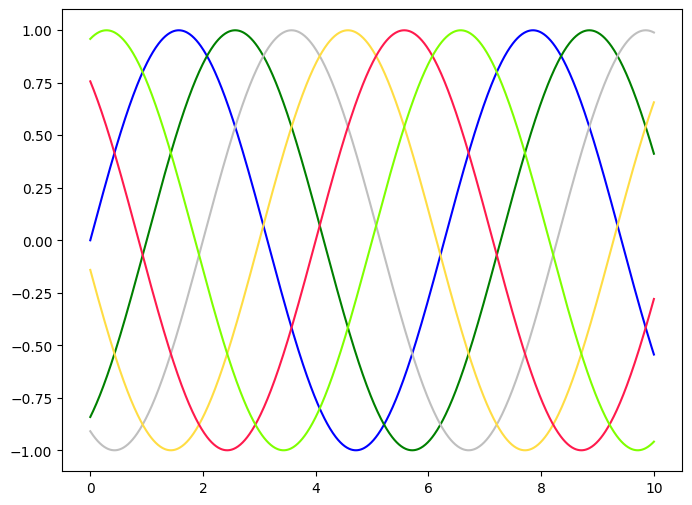

In [70]:
# specify color by name
plt.plot(x, np.sin(x), color='blue')
# short color code (rgbcmyk)
plt.plot(x, np.sin(x - 1), color='g')
# Grayscale between 0 and 1
plt.plot(x, np.sin(x - 2), color='0.75')
# Hex code (RRGGBB from 00 to FF)
plt.plot(x, np.sin(x - 3), color='#FFDD44')
# # RGB tuple, values 0 to 1
plt.plot(x, np.sin(x - 4), color=(1.0, 0.1, 0.3))
# # all HTML color names supported
plt.plot(x, np.sin(x - 5), color='chartreuse');

If no color is specified, Matplotlib will automatically cycle through a set of default colors for multiple lines.
Similarly, the line style can be adjusted using the **linestyle** keyword:

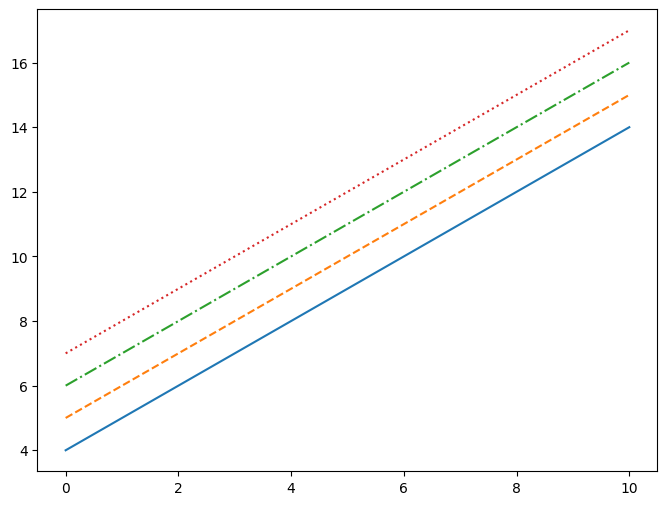

In [71]:
# plt.plot(x, x + 0, linestyle='solid')
# plt.plot(x, x + 1, linestyle='dashed')
# plt.plot(x, x + 2, linestyle='dashdot')
# plt.plot(x, x + 3, linestyle='dotted');

# For short, you can use the following codes:
plt.plot(x, x + 4, linestyle='-')  # solid
plt.plot(x, x + 5, linestyle='--') # dashed
plt.plot(x, x + 6, linestyle='-.') # dashdot
plt.plot(x, x + 7, linestyle=':');  # dotted

**linestyle** and **color** codes can be combined into a single non-keyword argument to the plt.plot() function:

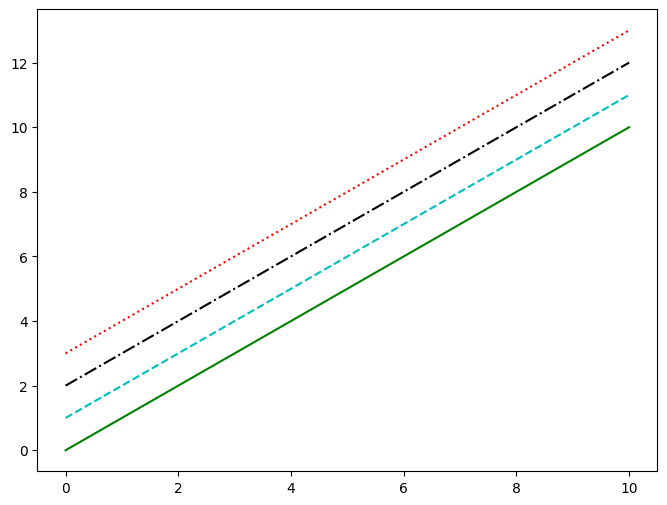

In [72]:
plt.plot(x, x + 0, '-g')  # solid green
plt.plot(x, x + 1, '--c') # dashed cyan
plt.plot(x, x + 2, '-.k') # dashdot black
plt.plot(x, x + 3, ':r');  # dotted red

## Adjusting the Plot: Axes Limits
Matplotlib does a decent job of choosing default axes limits for your plot, but sometimes it's nice to have finer control. The most basic way to adjust axis limits is to use the `plt.xlim()` and `plt.ylim()` methods:

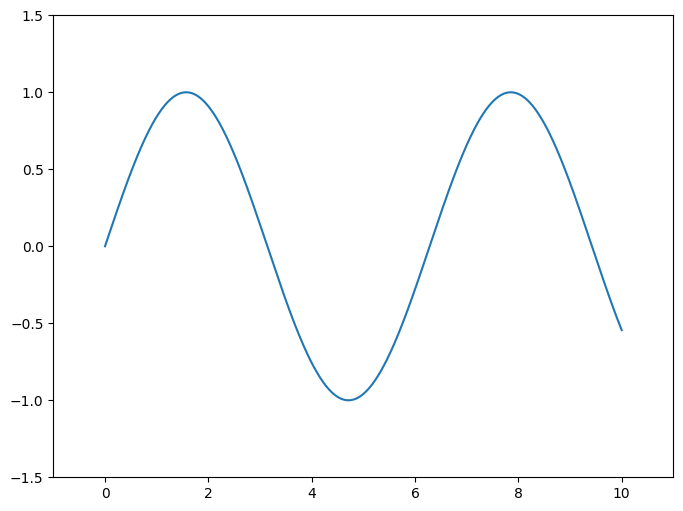

In [73]:
plt.plot(x, np.sin(x))

plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5);

If for some reason you'd like either axis to be displayed in reverse, you can simply reverse the order of the arguments:

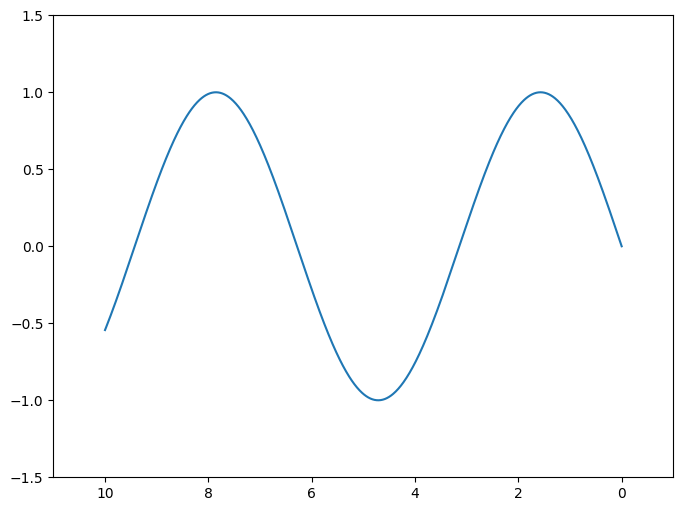

In [74]:
plt.plot(x, np.sin(x))

plt.xlim(11, -1) # reversed
plt.ylim(-1.5, 1.5);

A useful related method is `plt.axis()` (note here the potential confusion between **axes** with an **e**, and **axis** with an **i**). The `plt.axis()` method allows you to set the x and y limits with a single call, by passing a list which specifies `[xmin, xmax, ymin, ymax]`:

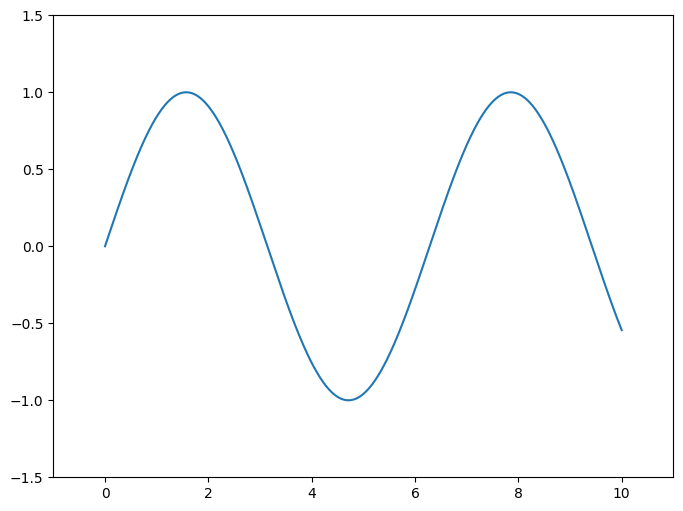

In [75]:
plt.plot(x, np.sin(x))
plt.axis([-1, 11, -1.5, 1.5]);

The **plt.axis()** method goes even beyond this, allowing you to do things like automatically tighten the bounds around the current plot:

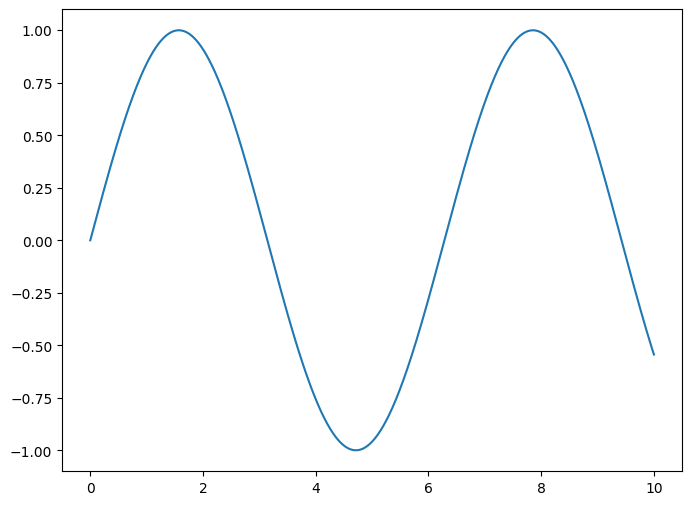

In [76]:
plt.plot(x, np.sin(x))
plt.axis('tight');

It allows even higher-level specifications, such as ensuring an equal aspect ratio so that on your screen, one unit in x is equal to one unit in y.
(For more information on axis limits and the other capabilities of the **plt.axis** method, refer to the **plt.axis** docstring.)

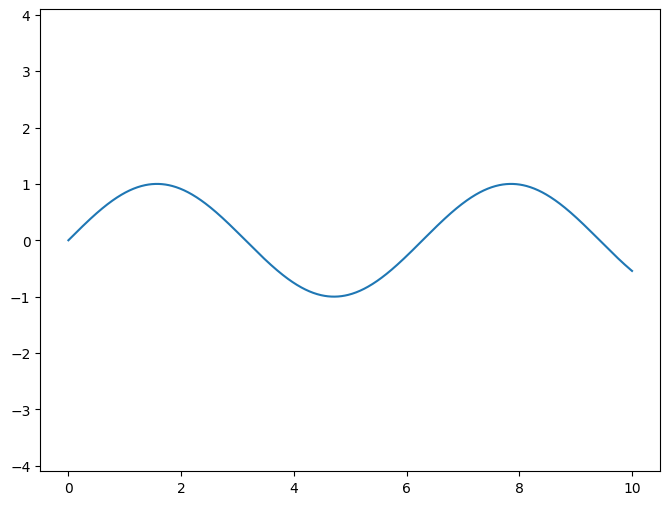

In [77]:
plt.plot(x, np.sin(x))
plt.axis('equal');

## Labeling Plots
Here we speak about labeling of plots: titles, axis labels, and simple legends.

Titles and axis labels are the simplest such labels—there are methods that can be used to quickly set them:

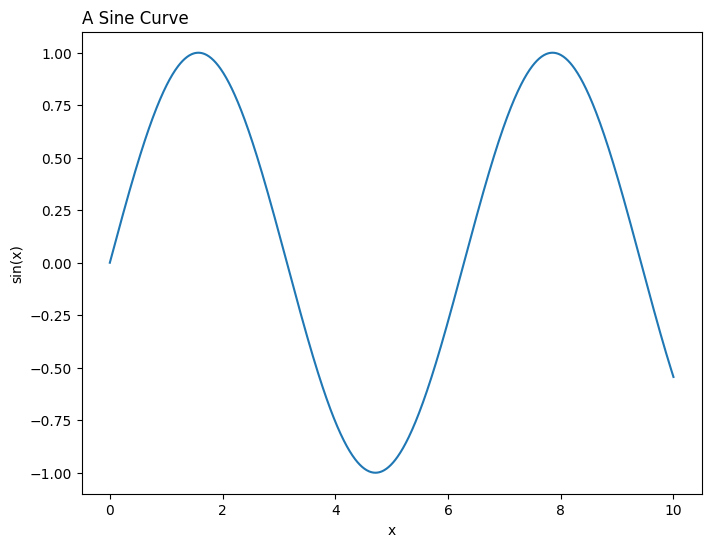

In [78]:
plt.plot(x, np.sin(x))
plt.title("A Sine Curve", loc='left') # by default the title is centered
plt.xlabel("x")
plt.ylabel("sin(x)");

The position, size, and style of these labels can be adjusted using optional arguments to the function

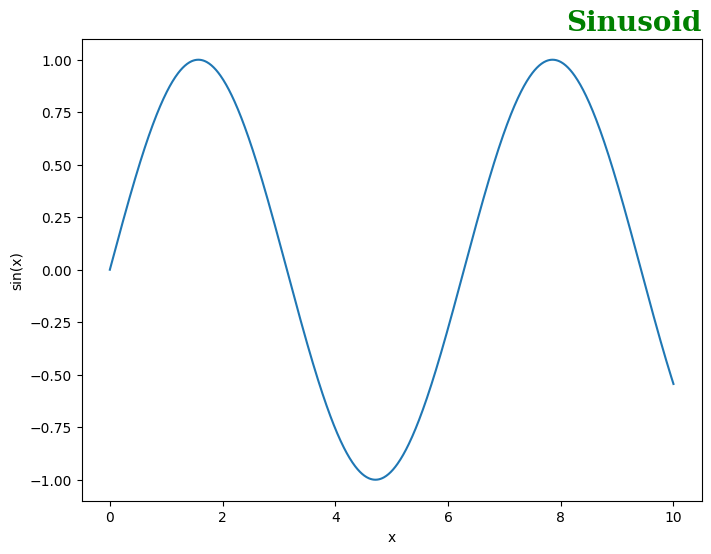

In [79]:
font = {'family': 'serif',
        'color':  'green',
        'weight': 'bold',
        'size': 20}

plt.plot(x, np.sin(x))

# by default the title is centered
# and can be changed with 'loc' argument
plt.title("Sinusoid", loc='right',  fontdict=font)
plt.xlabel("x")
plt.ylabel("sin(x)");

# Scatter Plots
Another commonly used plot type is the simple scatter plot, a close cousin of the line plot. Instead of points being joined by line segments, here the points are represented individually with a dot, circle, or other shape.

## Scatter Plots with `plt.plot`
We used **plt.plot** and **ax.plot** to produce line plots. It turns out that the same function can produce scatter plots as well.


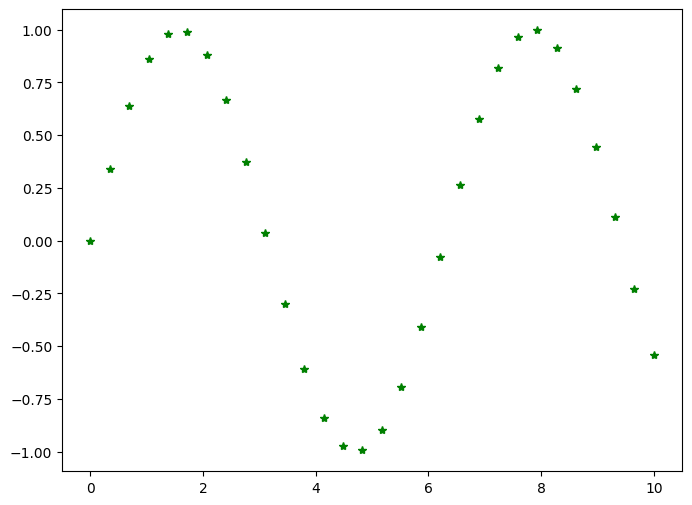

In [80]:
# notice that this line adds grid to the figure
#plt.style.use('ggplot')
x = np.linspace(0, 10, 30)
y = np.sin(x)

plt.plot(x, y, '*', color='green');
# plt.plot(x, y, color='green');

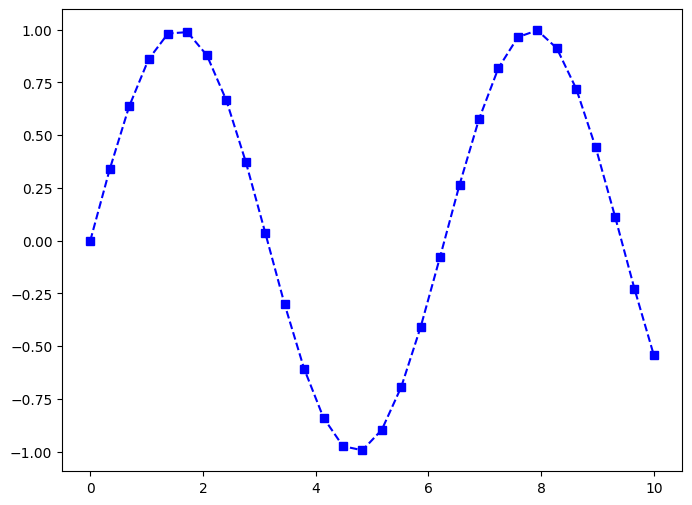

In [81]:
x = np.linspace(0, 10, 30)
y = np.sin(x)
plt.plot(x, y, '--sb');

The third argument in the function call is a character that represents the type of symbol used for the plotting. The full list of available symbols can be seen in the documentation of plt.plot ([About Matplotlib Markers](https://matplotlib.org/api/markers_api.html)).

Most of the possibilities are fairly intuitive, and we'll show a number of the more common ones here:

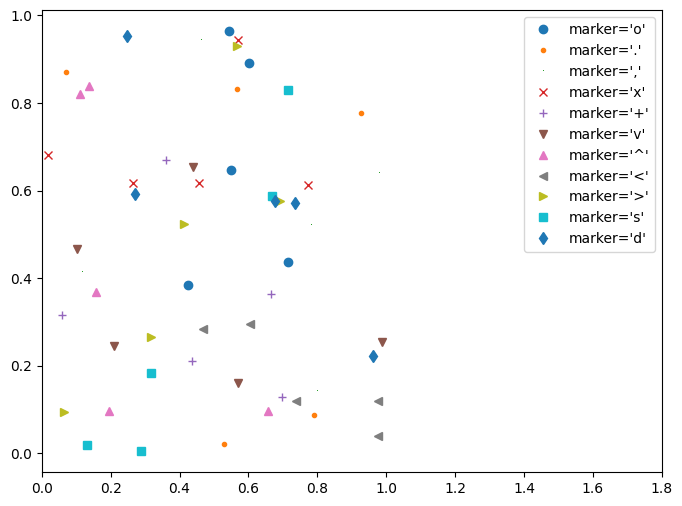

In [82]:
rng = np.random.RandomState(0)
markers = ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']
for marker in markers:
    plt.plot(rng.rand(5), rng.rand(5), marker,
             label="marker='{0}'".format(marker))
plt.legend(numpoints=1)
plt.xlim(0, 1.8);

For even more possibilities, these character codes can be used together with line and color codes to plot points along with a line connecting them:

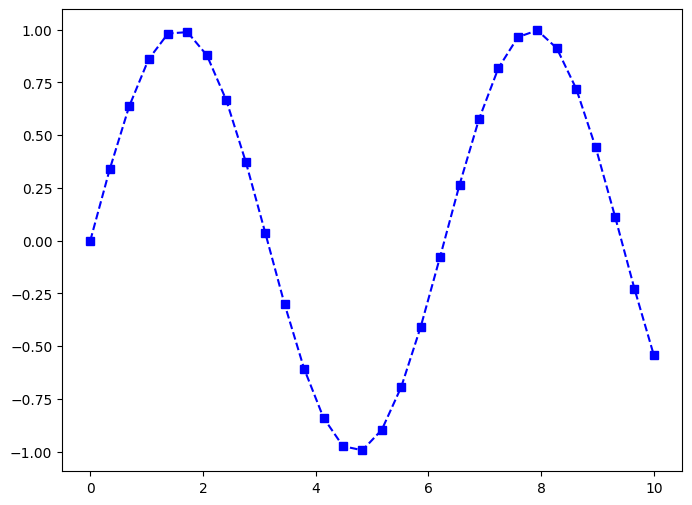

In [83]:
plt.plot(x, y, '--sb');

Additional keyword arguments to **plt.plot** specify a wide range of properties of the lines and markers:

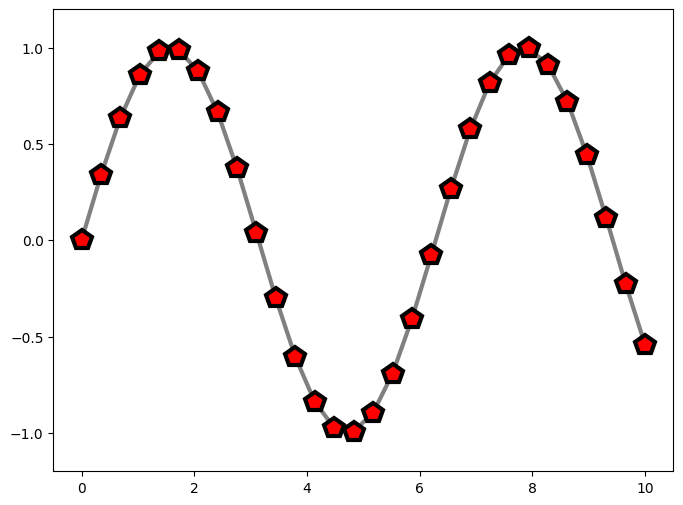

In [84]:
plt.plot(x, y, '-p', color='gray',
         markersize=15, linewidth=3,
         markerfacecolor='red',
         markeredgecolor='black',
         markeredgewidth=3)
plt.ylim(-1.2, 1.2);

## Scatter Plots with `plt.scatter`
A second, more powerful method of creating scatter plots is the `plt.scatter` function, which can be used very similarly to the **plt.plot** function:

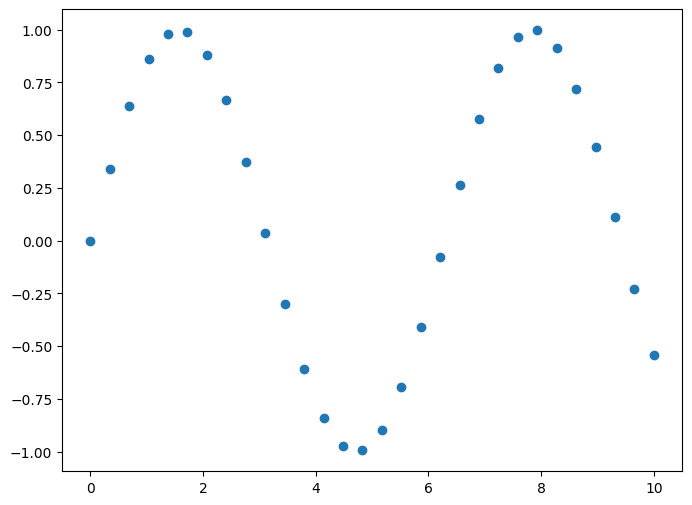

In [85]:
plt.scatter(x, y);

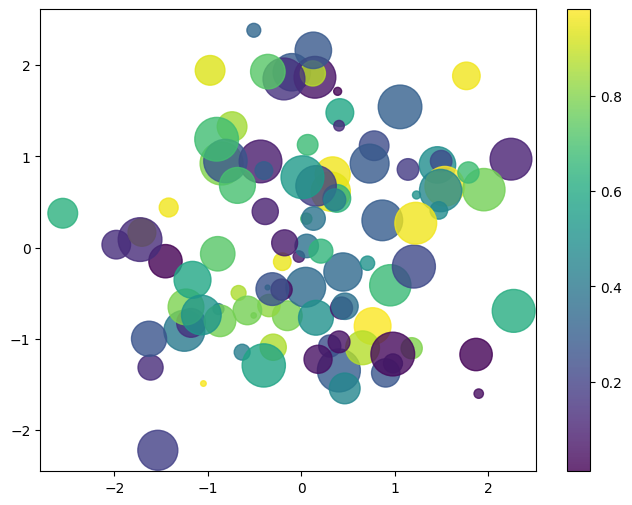

In [86]:
rng = np.random.RandomState(0)
x = rng.randn(100)
y = rng.randn(100)
colors = rng.rand(100)
sizes = 1000 * rng.rand(100)

plt.scatter(x, y, c=colors, s=sizes, alpha=0.8,
            cmap='viridis')
plt.colorbar();  # show color scale

Notice that the **color** argument is automatically mapped to a color scale (shown here by the **colorbar()** command), and that the **size** argument is given in pixels.

It is important to stress that, as datasets get larger than a few thousand points, `plt.plot` can be noticeably more efficient than `plt.scatter`. The reason is that `plt.scatter` has the capability to render a different size and/or color for each point, so the renderer must do the extra work of constructing each point individually.

# Visualizing Errors
For any scientific measurement, accurate accounting for errors is nearly as important, if not more important, than accurate reporting of the number itself.

In visualization of data and results, showing these errors effectively can make a plot convey much more complete information.

A basic errorbar can be created with a single Matplotlib function call:

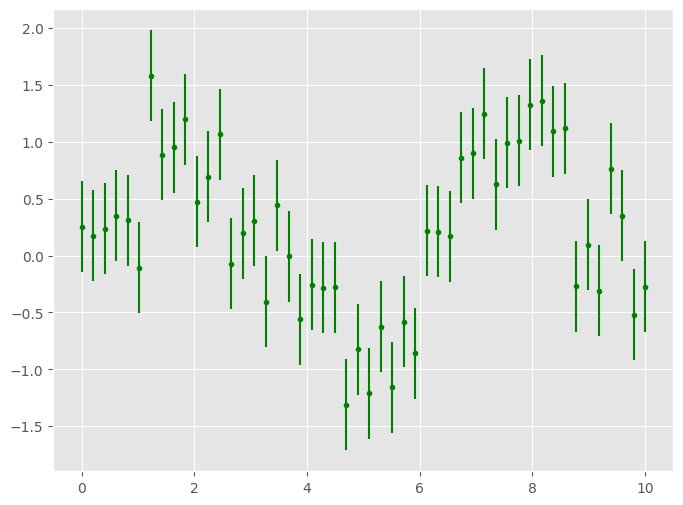

In [87]:
plt.style.use('ggplot')

x = np.linspace(0, 10, 50)
dy = 0.4
y = np.sin(x) + dy * np.random.randn(50)

plt.errorbar(x, y, yerr=dy, fmt='.g');

The **errorbar** function has many options to fine-tune the outputs.

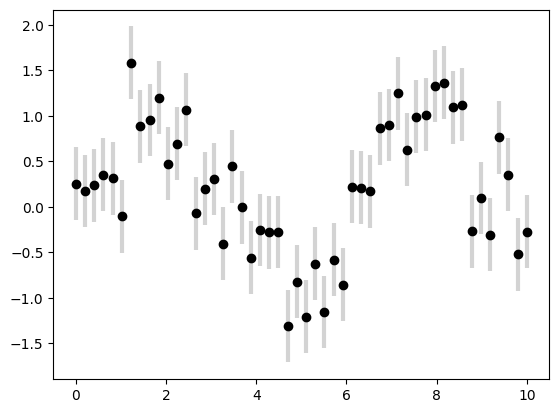

In [88]:
plt.style.use('default')
plt.errorbar(x, y, yerr=dy, fmt='o', color='black',
              ecolor='lightgray',  elinewidth=3, capsize=0);

**Note**
Read [Continuous Errors](https://plot.ly/python/v3/continuous-error-bars/) for more advanced knowledge.


# Histogram, Binnings and Box plot
Here, as a first step we will create a simple histogram.

In [92]:
# let's change of the plot style
#plt.style.use('seaborn-white')

# Generate 1000 random numbers with Gaussian distribution.
data = np.random.randn(1000)

In [90]:
data.min(), data.max()

(1.0, 3.0)

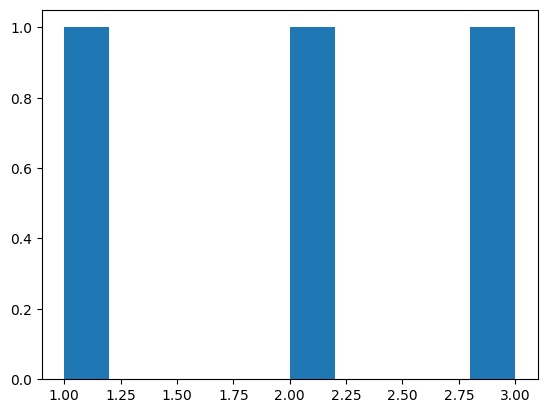

In [91]:
plt.hist(data);

The **hist()** function has many options to tune both the calculation and the display; here's an example of a more customized histogram:

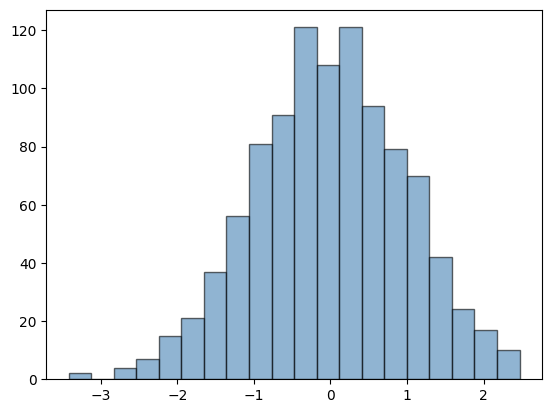

In [93]:
plt.hist(data, bins=20, alpha=0.6,
         histtype='bar', color='steelblue',
         edgecolor='black');
# histtype's possible values are {'bar', 'barstacked', 'step', 'stepfilled'},
# optional edgecolor specifies color for edges

The combination of **histtype='stepfilled'** along with some transparency **alpha** is very useful when comparing histograms of several distributions:

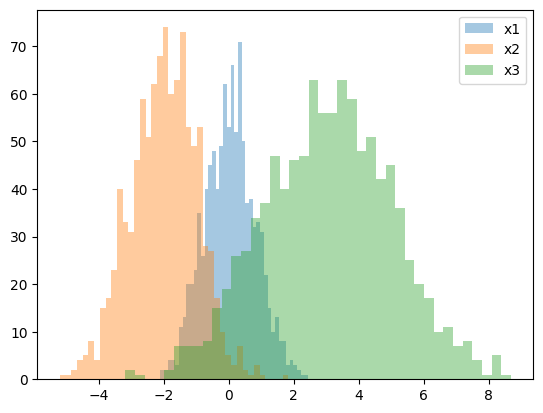

In [95]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

# Usage if kwargs makes things more generic, so you
# can add or remove options in kwargs.

kwargs = dict(histtype='stepfilled', alpha=0.4, bins=40)

plt.hist(x1, label='x1', **kwargs)
plt.hist(x2, label='x2', **kwargs)
plt.hist(x3, label='x3', **kwargs)
plt.legend();

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the **np.histogram()** function is available:

In [96]:
# Demonstrates the data with specified number of bins.
# counts is the number of points in each bin
# bin_edges shows the limits of each bin
counts, bin_edges = np.histogram(data, bins=10)
print(counts)
print(bin_edges)

[  2  11  36  93 172 229 215 149  66  27]
[-3.42231035 -2.83298349 -2.24365662 -1.65432976 -1.0650029  -0.47567604
  0.11365083  0.70297769  1.29230455  1.88163142  2.47095828]


## Two-Dimensional Histograms and Binnings
Just as we create histograms in one dimension by dividing the number-line into bins, we can also create histograms in two-dimensions by dividing points among two-dimensional bins. We'll start by defining some data—an x and y array drawn from a multivariate Gaussian distribution:

In [97]:
mean = [0, 0]
cov = [[1, 1],
       [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

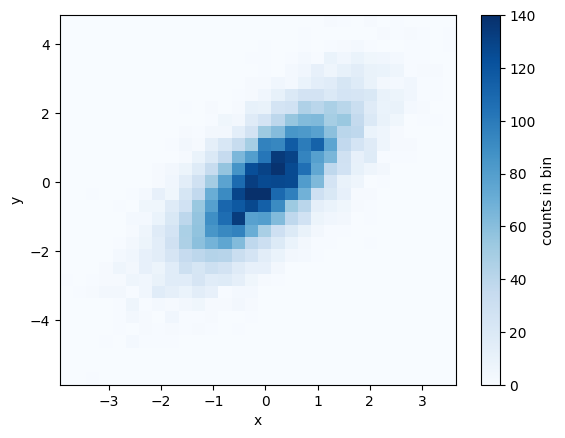

In [98]:
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')
plt.xlabel('x')
plt.ylabel('y');

Just as **plt.hist** has a counterpart in **np.histogram**, **plt.hist2d** has a counterpart in **np.histogram2d**, which can be used as follows:

In [99]:
counts, xedges, yedges = np.histogram2d(x, y, bins=10)
print(counts.shape)
print(xedges.shape)
print(yedges.shape)

(10, 10)
(11,)
(11,)


## Hexagonal binnings
The function `plt.hist2d()` uses rectangular bins to construct a two dimensional histogram. As an alternative, the function `plt.hexbin()` uses hexagonal bins.

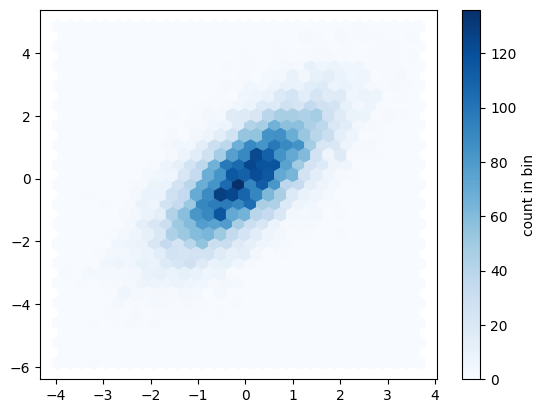

In [100]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

## Box plot

In descriptive statistics, a box plot (or `boxplot`) is a method for graphically depicting groups of numerical data through their quartiles. `Boxplots` may also have lines extending from the boxes (whiskers) indicating variability outside the upper and lower quartiles, hence sometimes it's called box-and-whisker plot. Outliers may be plotted as individual points.

/tmp/ipython-input-493080076.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x1, x2], labels=['N(0, 0.8)', 'N(-2, 2)'])


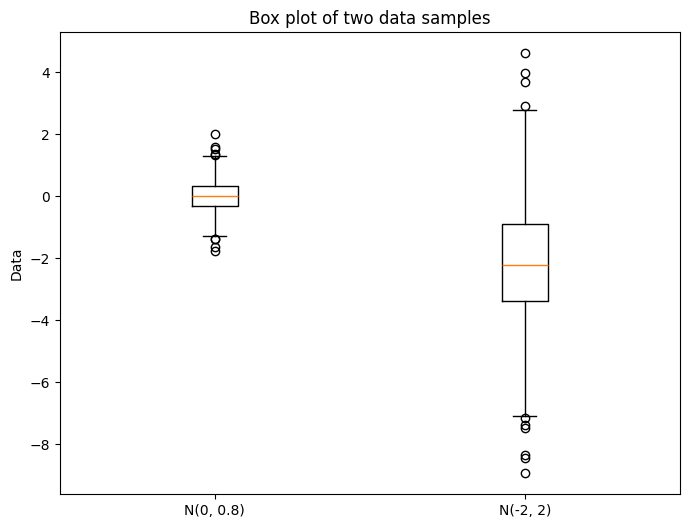

In [128]:
x1 = np.random.normal(0, 0.5, 1000)
x2 = np.random.normal(-2, 2, 1000)
plt.title('Box plot of two data samples')
plt.boxplot([x1, x2], labels=['N(0, 0.8)', 'N(-2, 2)'])
plt.ylabel('Data')
plt.show()

In [129]:
a = np.quantile(x2, [0, 0.25, 0.5, 0.75, 1])
IQR = a[3] - a[1]
minn = a[1] - 1.5 * IQR
maxx = a[3] + 1.5 * IQR
print(minn, maxx)

-7.0888149232365 2.8025499363685453


# Customizing Plot Legends
Plot legends give meaning to a visualization, assigning meaning to the various plot elements. We previously saw how to create a simple legend; here we'll take a look at customizing the placement and aesthetics of the legend in Matplotlib.

The simplest legend can be created with the **plt.legend()** command, which automatically creates a legend for any labeled plot elements:

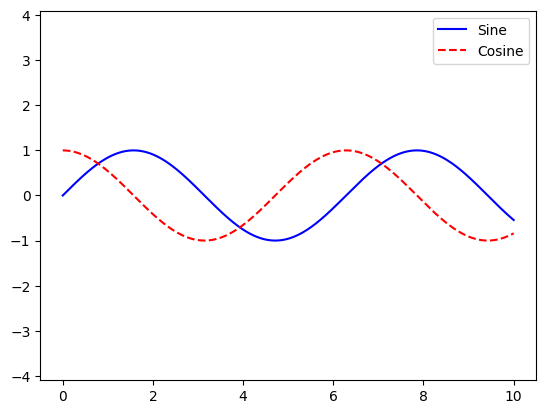

In [103]:
x = np.linspace(0, 10, 1000)
# instead of using fig = plt.figure() and ax = plt.axes()
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), '-b', label='Sine')
ax.plot(x, np.cos(x), '--r', label='Cosine')
ax.axis('equal')
leg = ax.legend();

There are many ways we might want to customize such a legend. For example, we can specify the location and turn off the frame:

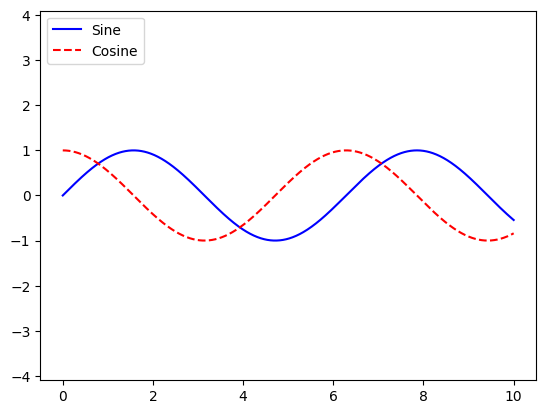

In [104]:
ax.legend(loc='upper left')
fig

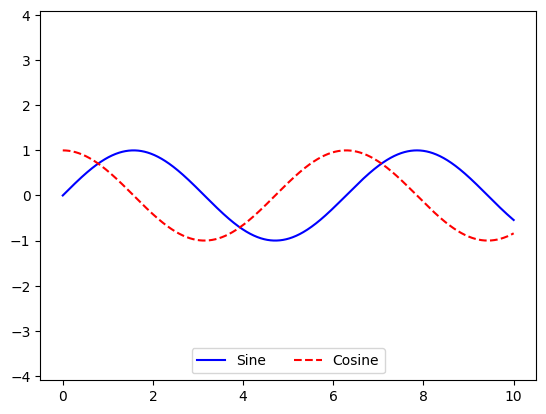

In [105]:
# ncol specifies the number of columns for labels
ax.legend(loc='lower center', ncol=2)
fig

## Multiple Legends
Sometimes when designing a plot you'd like to add multiple legends to the same axes. Unfortunately, Matplotlib does not make this easy: via the standard legend interface, it is only possible to create a single legend for the entire plot. If you try to create a second legend using **plt.legend()** or **ax.legend()**, it will simply override the first one. We can work around this by creating a new legend artist from scratch, and then using the lower-level **ax.add_artist()** method to manually add the second artist to the plot:


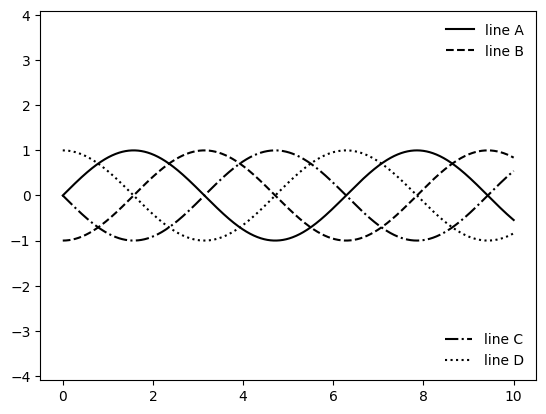

In [107]:
plt.style.use('default')
fig, ax = plt.subplots() # create figure and axes

lines = []
styles = ['-', '--', '-.', ':']
x = np.linspace(0, 10, 1000)

for i in range(4):
    lines += ax.plot(x, np.sin(x - i * np.pi / 2),
                     styles[i], color='black')
ax.axis('equal')

# specify the lines and labels of the first legend
ax.legend(lines[:2], ['line A', 'line B'],
          loc='upper right', frameon=False)

# Create the second legend and add the artist manually.
from matplotlib.legend import Legend
leg = Legend(ax, lines[2:], ['line C', 'line D'],
             loc='lower right', frameon=False)
ax.add_artist(leg);

## Customizing Colorbars
For continuous labels based on the color of points, lines, or regions, a labeled colorbar can be a great tool. In Matplotlib, a colorbar is a separate axes that can provide a key for the meaning of colors in a plot.

In [108]:
# x

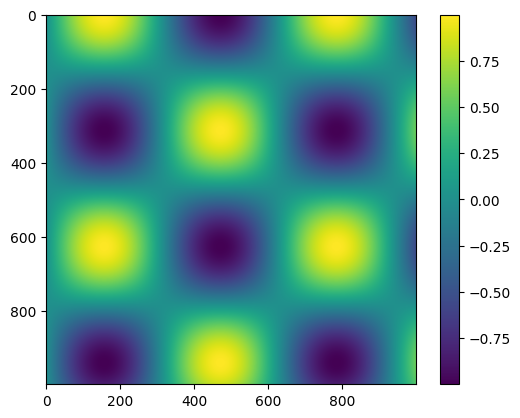

In [109]:
x = np.linspace(0, 10, 1000)
I = np.sin(x) * np.cos(x[:, np.newaxis]) # 1000 x 1000

plt.imshow(I)
plt.colorbar();

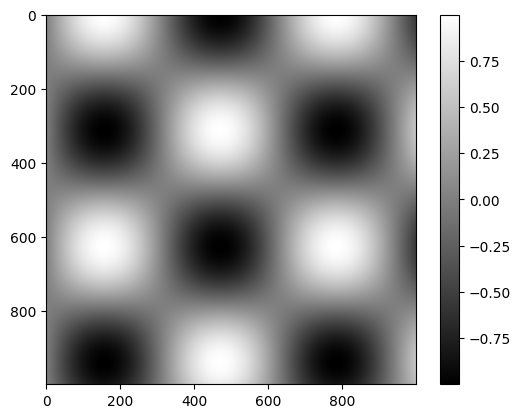

In [110]:
# colormap can be specified using the cmap
plt.imshow(I, cmap='gray')
plt.colorbar();

# Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. To this end, Matplotlib has the concept of subplots: groups of smaller axes that can exist together within a single figure. These subplots might be insets, grids of plots, or other more complicated layouts. In this section we'll explore four routines for creating subplots in Matplotlib.

## `plt.axes` : Subplots by Hand
The most basic method of creating an axes is to use the plt.axes function. As we've seen previously, by default this creates a standard axes object that fills the entire figure. plt.axes also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent [left, bottom, width, height] in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.65, 0.65, 0.2, 0.2])

The equivalent of this command within the object-oriented interface is **fig.add_axes()**.

In [ ]:
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))

ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

## `plt.subplot` : Simple Grids of Subplots
Aligned columns or rows of subplots are very commonly needed, hence Matplotlib has several convenience routines that make them easy to create. The lowest level of these is **plt.subplot()**.

In [ ]:
for i in range(1, 7):
    plt.subplot(2, 3, i)
    plt.plot(x, np.sin(x*i))
    # plt.text(0.5, 0.5, str((2, 3, i)),
    #          fontsize=18, ha='center')

The command **plt.subplots_adjust** can be used to adjust the spacing between these plots. The following code uses the equivalent object-oriented command, **fig.add_subplot()**:

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

# Three-Dimensional Plotting in Matplotlib

Three-dimensional plots are enabled by importing the mplot3d toolkit, included with the main Matplotlib installation

In [111]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

Once this submodule is imported, a three-dimensional axes can be created by passing the keyword **projection='3d'** to any of the normal axes creation routines:

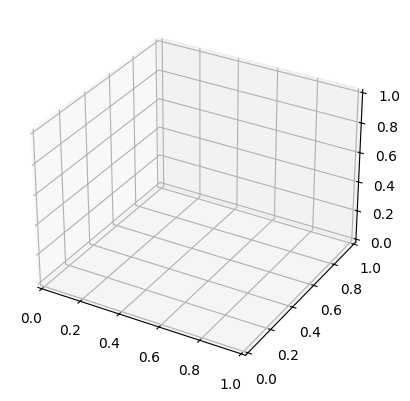

In [112]:
ax = plt.axes(projection='3d')

With this three-dimensional axes enabled, we can now plot a variety of three-dimensional plot types.

## Three-dimensional Points and Lines
The most basic three-dimensional plot is a line or collection of scatter plot created from sets of (x, y, z) triples. In analogy with the more common two-dimensional plots discussed earlier, these can be created using the **ax.plot3D** and **ax.scatter3D** functions.

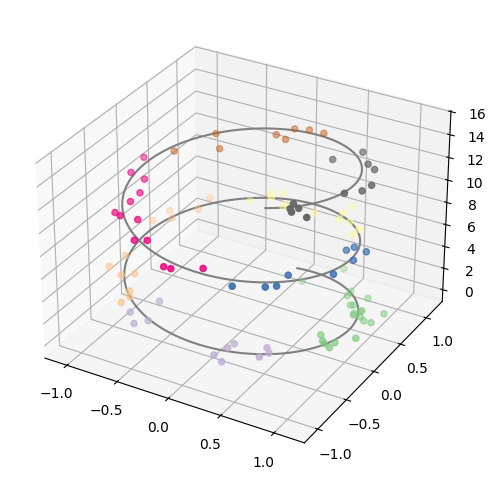

In [113]:
plt.rcParams['figure.figsize'] = 8, 6

ax = plt.axes(projection='3d')
zline = np.linspace(0, 15, 1000)
xline = np.sin(zline)
yline = np.cos(zline)
ax.plot3D(xline, yline, zline, 'gray')

# Data for three-dimensional scattered points
zdata = 15 * np.random.random(100)
xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
ydata = np.cos(zdata) + 0.1 * np.random.randn(100)
ax.scatter3D(xdata, ydata, zdata, c=zdata, cmap='Accent');

## Three-dimensional Contour Plots
Like two-dimensional **ax.contour** plots, **ax.contour3D** requires all the input data to be in the form of two-dimensional regular grids, with the Z data evaluated at each point. Here we'll show a three-dimensional contour diagram of a three-dimensional sinusoidal function:

In [114]:
def f(x, y):
    return np.sin(np.sqrt(x ** 2 + y ** 2))

x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

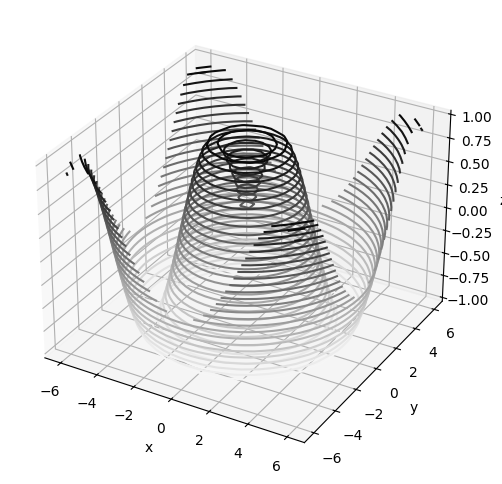

In [115]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 30, cmap='binary')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

Sometimes the default viewing angle is not optimal, in which case we can use the **view_init** method to set the elevation and azimuthal angles. In the following example, we'll use an elevation of 60 degrees (that is, 60 degrees above the x-y plane) and an azimuth of 70 degrees (that is, rotated 70 degrees counter-clockwise about the z-axis):

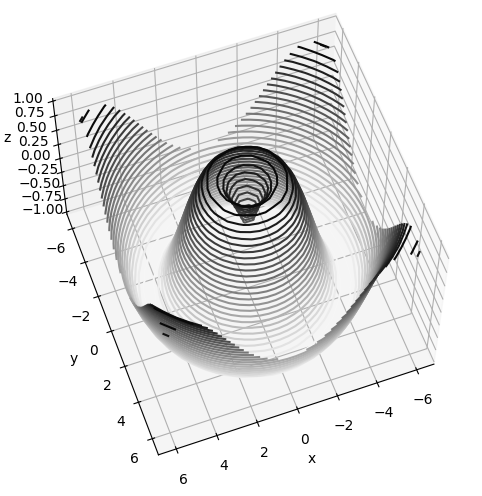

In [116]:
# %matplotlib inline
ax.view_init(60, 70)
fig

## Surface Triangulation

Triangulation of a surface is the procedure of generating a net of triangles, which covers a given surface partly or totally.

Suppose we have a set of random points in Polar coordinates $(r, \phi)$ and we want to see the surface of a function $f(x, y)$ obtained from the corresponding Cartesian points $(x,y)$.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Polar_to_cartesian.svg/375px-Polar_to_cartesian.svg.png)

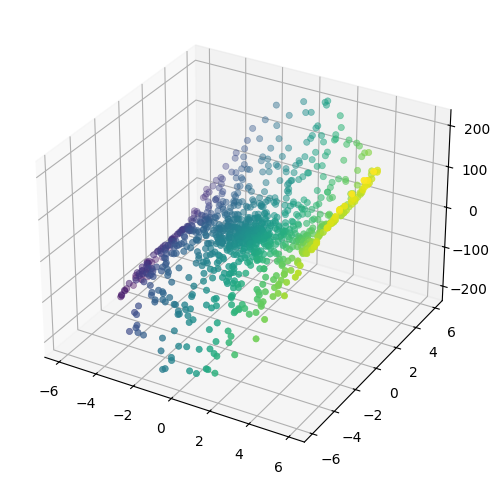

In [117]:
plt.rcParams['figure.figsize'] = 8, 6

f = lambda x, y: x ** 3 + y ** 3
phi = 2 * np.pi * np.random.random(1000)
r = 6 * np.random.random(1000)
x = r * np.sin(phi)
y = r * np.cos(phi)
z = f(x, y)
ax = plt.axes(projection='3d')
ax.scatter(x, y, z, c=x, cmap='viridis', linewidth=0.5);

We can use the `plot_triusurf()` function to plut the triangular surface.

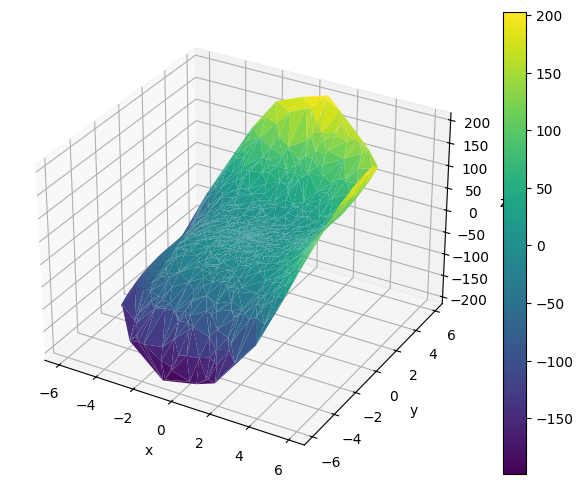

In [118]:
fig = plt.figure()
ax = plt.axes(projection='3d')
p = ax.plot_trisurf(x, y, z,
                cmap='viridis', edgecolor='none');

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

fig.colorbar(p);

# if we want to visualize from another angle
# ax.view_init(30, 120);

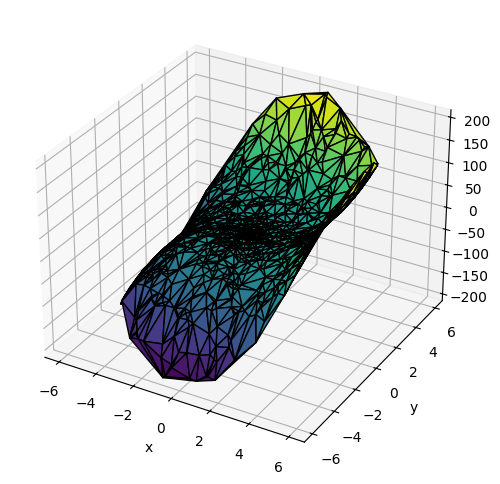

In [119]:
ax = plt.axes(projection='3d')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.plot_trisurf(x, y, z,
                cmap='viridis', edgecolor='k');


## Wireframes and Surface Plots
Two other types of three-dimensional plots that work on gridded data are wireframes and surface plots. These take a grid of values and project it onto the specified three-dimensional surface, and can make the resulting three-dimensional forms quite easy to visualize. Here's an example of using a wireframe:

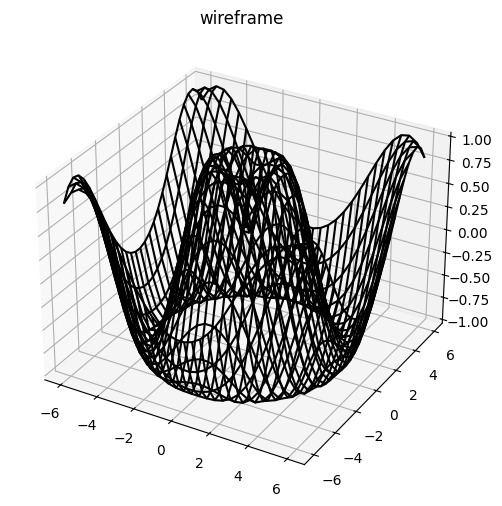

In [120]:
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='black')
ax.set_title('wireframe');

A surface plot is like a wireframe plot, but each face of the wireframe is a filled polygon. Adding a colormap to the filled polygons can aid perception of the topology of the surface being visualized:

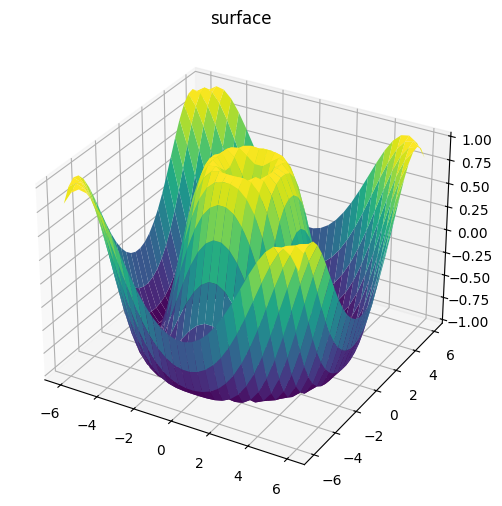

In [121]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('surface');

## 3D Bar Plots

Each bar in a bar plot always needs 2 things: a position and a size. With 3D bar plots, we're going to supply that information for all three variables $x, y, z$.
We will select the z axis to encode the height of each bar; therefore, each bar will start at $z = 0$ and have a size that is proportional to the value we are trying to visualise. The $x$ and $y$ positions will represent the coordinates of the bar across the 2D plane of $z = 0$. We'll set the $x$ and $y$ size of each bar to a value of $1$ so that all the bars have the same shape.

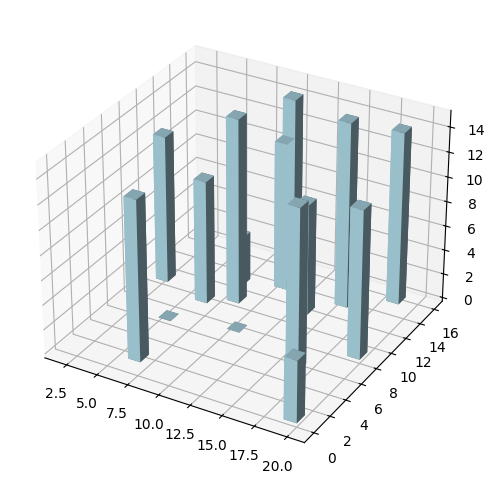

In [122]:
fig = plt.figure()
ax = plt.axes(projection="3d")

num_bars = 15
x_pos = np.random.choice(range(20), num_bars)
y_pos = np.random.choice(range(20), num_bars)
z_pos = np.zeros(num_bars)

x_size = np.ones(num_bars)
y_size = np.ones(num_bars)
z_size = np.random.choice(range(20), num_bars)

ax.bar3d(x_pos, y_pos, z_pos, x_size, y_size, z_size, color='lightblue')
plt.show()

When multiple lines are being shown within a single axes, it can be useful to create a plot legend that labels each line type. Again, Matplotlib has a built-in way of quickly creating such a legend. It is done via the **plt.legend()** method.

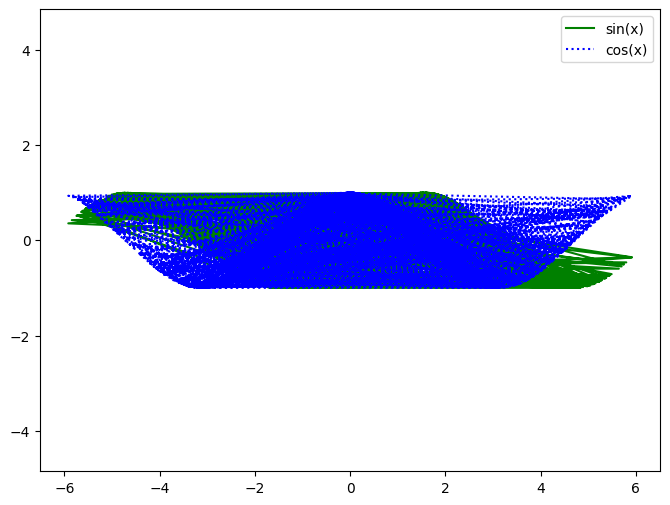

In [125]:
plt.plot(x, np.sin(x), '-g', label='sin(x)')
plt.plot(x, np.cos(x), ':b', label='cos(x)')
plt.axis('equal')

plt.legend();
# plt.legend(loc='upper left');

More information on specifying and formatting plot legends can be found in the **plt.legend** docstring [About Matplotlib Legend](https://matplotlib.org/api/legend_api.html).